In [1]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

MODEL_NAME       = 'ProsusAI/finbert'
MAX_TOKEN_LENGTH = 64
BATCH_SIZE       = 16
NUM_CLASSES      = 3
label_names      = ['Bearish', 'Bullish', 'Neutral']

print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {device}")
print(f"Model           : {MODEL_NAME}")

c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version : 2.11.0+cpu
Device          : cpu
Model           : ProsusAI/finbert


In [2]:
# Load Dataset 
def light_clean(text):
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train = pd.read_csv('../data/sent_train.csv')
valid = pd.read_csv('../data/sent_valid.csv')

train['text'] = train['text'].apply(light_clean)
valid['text'] = valid['text'].apply(light_clean)

train = train[train['text'].str.strip() != ''].reset_index(drop=True)
valid = valid[valid['text'].str.strip() != ''].reset_index(drop=True)

print(f"Train samples : {len(train)}")
print(f"Valid samples : {len(valid)}")

Train samples : 9540
Valid samples : 2388


In [3]:
# Load Tokenizer and Saved FinBERT Model 
print(f"Loading tokenizer from : {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"Loading model from     : {MODEL_NAME}")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels              = NUM_CLASSES,
    ignore_mismatched_sizes = True
)

# Load fine-tuned weights trained on Colab
model.load_state_dict(torch.load('../models/FinBERT_best.pt', map_location=device))
model = model.to(device)
model.eval()

print(f"\n✓ Fine-tuned FinBERT weights loaded from ../models/FinBERT_best.pt")
print(f"Total parameters : {sum(p.numel() for p in model.parameters()):,}")

Loading tokenizer from : ProsusAI/finbert


Loading model from     : ProsusAI/finbert


Loading weights: 100%|██████████| 201/201 [00:01<00:00, 164.72it/s, Materializing param=classifier.weight]                                      
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



✓ Fine-tuned FinBERT weights loaded from ../models/FinBERT_best.pt
Total parameters : 109,484,547


In [4]:
# BERT Dataset and DataLoader 
class BERTSentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length     = self.max_len,
            padding        = 'max_length',
            truncation     = True,
            return_tensors = 'pt'
        )
        return {
            'input_ids'      : encoding['input_ids'].squeeze(0),
            'attention_mask' : encoding['attention_mask'].squeeze(0),
            'label'          : torch.tensor(self.labels[idx], dtype=torch.long)
        }

valid_dataset = BERTSentimentDataset(
    valid['text'].tolist(), valid['label'].tolist(), tokenizer, MAX_TOKEN_LENGTH)

valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Valid samples : {len(valid_dataset)}")
print(f"Valid batches : {len(valid_loader)}")

Valid samples : 2388
Valid batches : 150


In [5]:
# Evaluate FinBERT on Validation Set 
all_preds, all_labels = [], []

model.eval()
with torch.no_grad():
    for batch in valid_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds   = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

bert_acc = accuracy_score(all_labels, all_preds)
bert_f1  = f1_score(all_labels, all_preds, average='macro')

print(f"FinBERT — Validation Results")
print(f"Accuracy  : {bert_acc:.4f}")
print(f"Macro F1  : {bert_f1:.4f}")
print()
print("FinBERT — Full Classification Report:")
print(classification_report(all_labels, all_preds, target_names=label_names, digits=4))

FinBERT — Validation Results
Accuracy  : 0.8790
Macro F1  : 0.8409

FinBERT — Full Classification Report:
              precision    recall  f1-score   support

     Bearish     0.7554    0.8098    0.7816       347
     Bullish     0.8184    0.8253    0.8218       475
     Neutral     0.9278    0.9106    0.9191      1566

    accuracy                         0.8790      2388
   macro avg     0.8338    0.8486    0.8409      2388
weighted avg     0.8810    0.8790    0.8798      2388



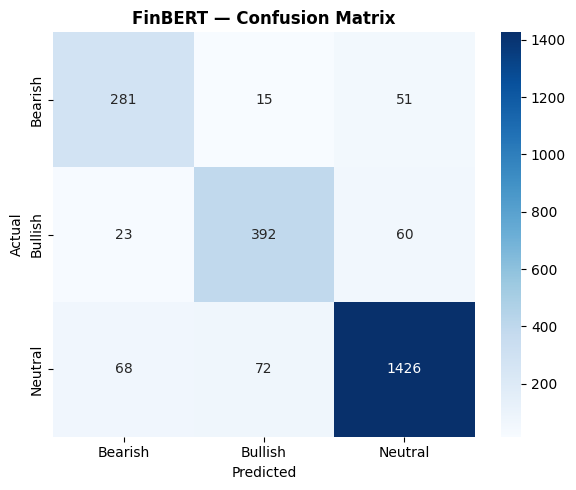

✓ Plot saved to assets/FinBERT_confusion_matrix.png


In [6]:
#Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names,
            yticklabels=label_names)
plt.title('FinBERT — Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../assets/FinBERT_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot saved to assets/FinBERT_confusion_matrix.png")

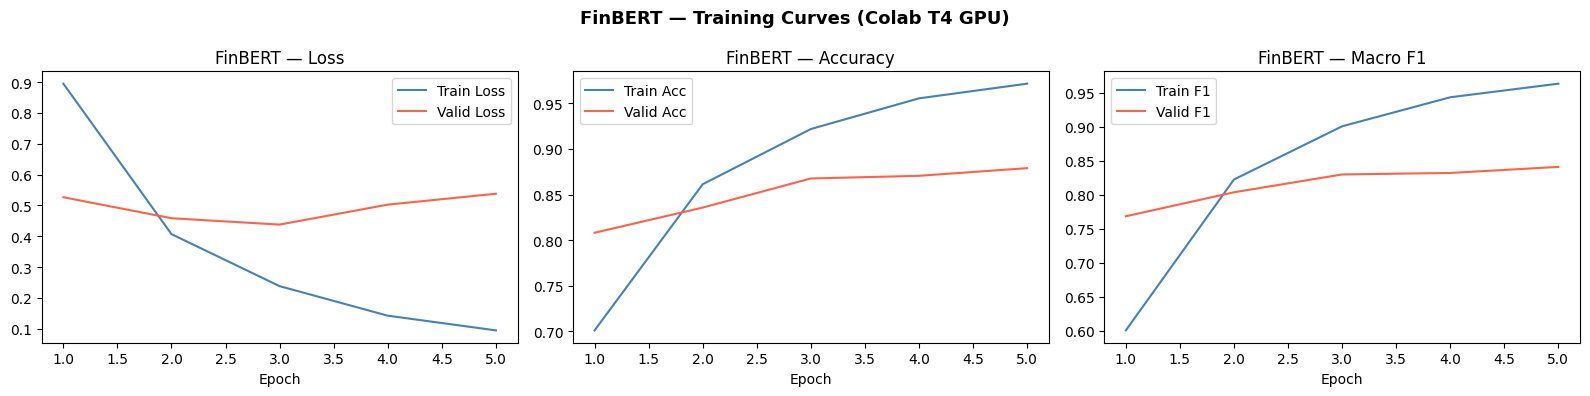

✓ Plot saved to assets/FinBERT_training_curves.png


In [7]:
#Training Curves — FinBERT (trained on Colab T4 GPU) 
bert_history = {
    'train_loss': [0.8946, 0.4069, 0.2383, 0.1426, 0.0949],
    'valid_loss': [0.5265, 0.4584, 0.4378, 0.5025, 0.5378],
    'train_acc' : [0.7012, 0.8614, 0.9219, 0.9555, 0.9716],
    'valid_acc' : [0.8082, 0.8358, 0.8677, 0.8706, 0.8790],
    'train_f1'  : [0.6005, 0.8224, 0.9006, 0.9433, 0.9633],
    'valid_f1'  : [0.7683, 0.8036, 0.8298, 0.8320, 0.8409],
}

epochs = range(1, 6)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epochs, bert_history['train_loss'], label='Train Loss', color='steelblue')
axes[0].plot(epochs, bert_history['valid_loss'], label='Valid Loss', color='tomato')
axes[0].set_title('FinBERT — Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs, bert_history['train_acc'], label='Train Acc', color='steelblue')
axes[1].plot(epochs, bert_history['valid_acc'], label='Valid Acc', color='tomato')
axes[1].set_title('FinBERT — Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(epochs, bert_history['train_f1'], label='Train F1', color='steelblue')
axes[2].plot(epochs, bert_history['valid_f1'], label='Valid F1', color='tomato')
axes[2].set_title('FinBERT — Macro F1')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.suptitle('FinBERT — Training Curves (Colab T4 GPU)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/FinBERT_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot saved to assets/FinBERT_training_curves.png")

         FINAL MODEL COMPARISON — All Models
    Model  Accuracy  Macro F1  Bearish F1  Bullish F1  Neutral F1
SimpleRNN    0.4380    0.3336      0.2196      0.1828      0.5983
      GRU    0.7956    0.7339      0.6257      0.7139      0.8623
     LSTM    0.8023    0.7355      0.6417      0.6899      0.8749
  FinBERT    0.8790    0.8409      0.7816      0.8218      0.9191


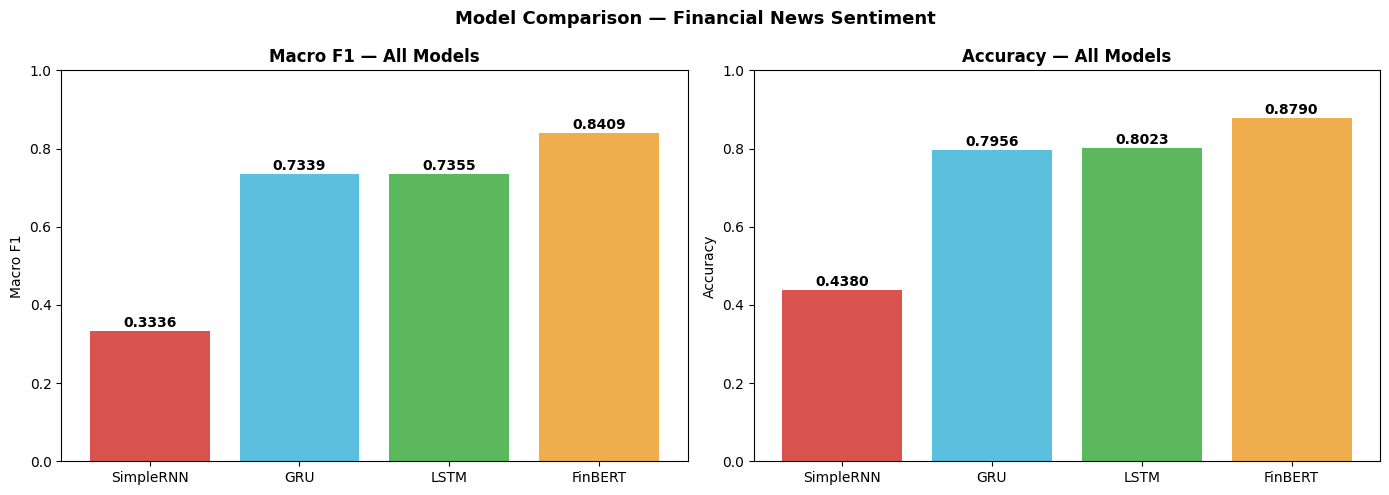

✓ Plot saved to assets/model_comparison.png


In [8]:
# Final Model Comparison — All Models 
comparison = {
    'Model'      : ['SimpleRNN', 'GRU', 'LSTM', 'FinBERT'],
    'Accuracy'   : [0.4380, 0.7956, 0.8023, 0.8790],
    'Macro F1'   : [0.3336, 0.7339, 0.7355, 0.8409],
    'Bearish F1' : [0.2196, 0.6257, 0.6417, 0.7816],
    'Bullish F1' : [0.1828, 0.7139, 0.6899, 0.8218],
    'Neutral F1' : [0.5983, 0.8623, 0.8749, 0.9191],
}

df_comparison = pd.DataFrame(comparison)
print("=" * 70)
print("         FINAL MODEL COMPARISON — All Models")
print("=" * 70)
print(df_comparison.to_string(index=False))
print("=" * 70)

# Plot Comparison 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models  = df_comparison['Model']
x       = range(len(models))
colors  = ['#d9534f', '#5bc0de', '#5cb85c', '#f0ad4e']

axes[0].bar(x, df_comparison['Macro F1'], color=colors)
axes[0].set_title('Macro F1 — All Models', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel('Macro F1')
for i, v in enumerate(df_comparison['Macro F1']):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

axes[1].bar(x, df_comparison['Accuracy'], color=colors)
axes[1].set_title('Accuracy — All Models', fontsize=12, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].set_ylim(0, 1.0)
axes[1].set_ylabel('Accuracy')
for i, v in enumerate(df_comparison['Accuracy']):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.suptitle('Model Comparison — Financial News Sentiment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot saved to assets/model_comparison.png")

In [9]:
# Summary 
print("=" * 65)
print("        PHASE 4 SUMMARY — FinBERT FINE-TUNING")
print("=" * 65)
print(f"""
TRAINING SETUP
  Model            : ProsusAI/finbert (finance-specific BERT)
  Platform         : Google Colab (Tesla T4 GPU)
  Reason           : CPU training caused hardware overheating
  MAX_TOKEN_LENGTH : 64
  BATCH_SIZE       : 32 (GPU) / 16 (local evaluation)
  EPOCHS           : 5
  LR               : 2e-5 (AdamW optimizer)
  Warmup steps     : 10% of total steps (149 steps)
  Gradient clipping: max_norm=1.0
  Loss function    : CrossEntropyLoss with class weights
  Early stopping   : patience=3 (not triggered — improved every epoch)

TRAINING RESULTS (Colab)
  Epoch 1 → Valid F1: 0.7683
  Epoch 2 → Valid F1: 0.8036
  Epoch 3 → Valid F1: 0.8298
  Epoch 4 → Valid F1: 0.8320
  Epoch 5 → Valid F1: 0.8409  ← best

FINAL EVALUATION (Local — FinBERT_best.pt)
  Accuracy         : 0.8790
  Macro F1         : 0.8409
  Bearish F1       : 0.7816
  Bullish F1       : 0.8218
  Neutral F1       : 0.9191

IMPROVEMENT OVER BEST RNN (LSTM)
  Macro F1         : 0.7355 → 0.8409  (+0.1054)
  Accuracy         : 0.8023 → 0.8790  (+0.0767)
  Bearish F1       : 0.6417 → 0.7816  (+0.1399)
  Bullish F1       : 0.6899 → 0.8218  (+0.1319)
  Neutral F1       : 0.8749 → 0.9191  (+0.0442)

KEY FINDING
  FinBERT outperforms all RNN models on every metric.
  Pre-trained financial domain knowledge gives significant
  advantage over training from scratch on limited data.

ARTIFACTS SAVED
  ../models/FinBERT_best.pt
  ../assets/FinBERT_confusion_matrix.png
  ../assets/FinBERT_training_curves.png
  ../assets/model_comparison.png
""")


        PHASE 4 SUMMARY — FinBERT FINE-TUNING

TRAINING SETUP
  Model            : ProsusAI/finbert (finance-specific BERT)
  Platform         : Google Colab (Tesla T4 GPU)
  Reason           : CPU training caused hardware overheating
  MAX_TOKEN_LENGTH : 64
  BATCH_SIZE       : 32 (GPU) / 16 (local evaluation)
  EPOCHS           : 5
  LR               : 2e-5 (AdamW optimizer)
  Warmup steps     : 10% of total steps (149 steps)
  Gradient clipping: max_norm=1.0
  Loss function    : CrossEntropyLoss with class weights
  Early stopping   : patience=3 (not triggered — improved every epoch)

TRAINING RESULTS (Colab)
  Epoch 1 → Valid F1: 0.7683
  Epoch 2 → Valid F1: 0.8036
  Epoch 3 → Valid F1: 0.8298
  Epoch 4 → Valid F1: 0.8320
  Epoch 5 → Valid F1: 0.8409  ← best

FINAL EVALUATION (Local — FinBERT_best.pt)
  Accuracy         : 0.8790
  Macro F1         : 0.8409
  Bearish F1       : 0.7816
  Bullish F1       : 0.8218
  Neutral F1       : 0.9191

IMPROVEMENT OVER BEST RNN (LSTM)
  Macro F